<a href="https://colab.research.google.com/github/doundo/ICT_voice_detect/blob/voice_detect/ICT_voice_detect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install noisereduce
!pip install --upgrade torch torchaudio --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201

In [4]:
import torch
import torch.nn as nn
import os
import numpy as np
import torchaudio
import torchaudio.transforms as T

# 1. DNN 모델 정의 (학습 시 구조 그대로)
class DNN(nn.Module):
    def __init__(self, input_dim=13, hidden_dim=32, output_dim=1):
        super(DNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))
        return x

# 2. 하이퍼파라미터 및 저장된 모델 경로
MODEL_PATH = "/content/drive/MyDrive/ICT_voice_detect_project/dnn_best_model.pt"
input_dim = 13
hidden_dim = 32
output_dim = 1

# 3. 모델 로드
model = DNN(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim)
model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device("cpu")))
model.eval()

# 4. MFCC 저차원 강조 가중치 (학습 시 사용한 값과 동일하게 유지)
mfcc_weights = torch.tensor([1.2 - 0.015 * i for i in range(13)], dtype=torch.float32)

# 5. MFCC 설정
#오디오를 16kHz로 통일
sample_rate = 16000
n_mfcc = 13
max_len = 300 #프레임 기준

#MFCC 변환 정의
mfcc_transform = T.MFCC(
    sample_rate=sample_rate,
    n_mfcc=n_mfcc,
    melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
)

#정규화 함수
def extract_mfcc_sequence_torch(path, max_len=300):
    waveform, sr = torchaudio.load(path)

    # 스테레오 → 모노 (2채널 평균)
    if waveform.size(0) > 1:
        waveform = waveform.mean(dim=0, keepdim=True)  # [1, T]

    if sr != sample_rate:
        resampler = T.Resample(sr, sample_rate)
        waveform = resampler(waveform)

    mfcc = mfcc_transform(waveform)  # [1, n_mfcc, time]
    mfcc = mfcc.squeeze(0).T         # [time, n_mfcc]

    # 패딩 (자르지 않음)
    if mfcc.size(0) < max_len:
        pad = torch.zeros((max_len - mfcc.size(0), mfcc.size(1)))
        mfcc = torch.cat([mfcc, pad], dim=0)

    return mfcc.numpy()

# 6. 추론 함수 정의
def predict_mfcc_vector(mfcc_input):
    """
    Args:
        mfcc_input: numpy array or list
                    shape (300, 13) or (13,)
    Returns:
        (probability, predicted_label)
    """
    if isinstance(mfcc_input, list):
        mfcc_input = np.array(mfcc_input, dtype=np.float32)

    # (300, 13) → 평균 벡터로 축소
    if mfcc_input.ndim == 2 and mfcc_input.shape[1] == 13:
        mfcc_vector = mfcc_input.mean(axis=0)
    elif mfcc_input.shape == (13,):
        mfcc_vector = mfcc_input
    else:
        raise ValueError("MFCC input must have shape (13,) or (N,13)")

    # 강조 가중치 적용
    weighted_vector = mfcc_vector * mfcc_weights.numpy()

    # 텐서 변환 및 추론
    input_tensor = torch.tensor(weighted_vector).unsqueeze(0)  # shape: (1, 13)
    with torch.no_grad():
        prob = model(input_tensor).item()

    label = int(prob >= 0.5)  # 0: 타인 음성, 1: 내 음성
    return prob, label


# 7. 예시 입력 및 실행
base_voice = "/content/drive/MyDrive/ICT_voice_detect_project/도언 나는 모르겠다.wav"

example_mfcc = extract_mfcc_sequence_torch(os.path.join(base_voice), max_len)

probability, prediction = predict_mfcc_vector(example_mfcc)

print(f"🔍 예측 확률: {probability:.4f} → 예측 라벨: {prediction} (1: 내 음성, 0: 타인)")


🔍 예측 확률: 0.0287 → 예측 라벨: 0 (1: 내 음성, 0: 타인)


Epoch 01 | Train Loss: 1.5354 | Val Loss: 0.0512 | Val Acc: 0.9805
✅ Best model saved.
Epoch 02 | Train Loss: 0.1056 | Val Loss: 0.0202 | Val Acc: 0.9915
✅ Best model saved.
Epoch 03 | Train Loss: 0.0591 | Val Loss: 0.0129 | Val Acc: 0.9967
✅ Best model saved.
Epoch 04 | Train Loss: 0.0372 | Val Loss: 0.0094 | Val Acc: 0.9967
✅ Best model saved.
Epoch 05 | Train Loss: 0.0291 | Val Loss: 0.0082 | Val Acc: 0.9981
✅ Best model saved.
Epoch 06 | Train Loss: 0.0221 | Val Loss: 0.0061 | Val Acc: 0.9986
✅ Best model saved.
Epoch 07 | Train Loss: 0.0203 | Val Loss: 0.0049 | Val Acc: 0.9986
✅ Best model saved.
Epoch 08 | Train Loss: 0.0160 | Val Loss: 0.0049 | Val Acc: 0.9986
✅ Best model saved.
Epoch 09 | Train Loss: 0.0177 | Val Loss: 0.0044 | Val Acc: 0.9991
✅ Best model saved.
Epoch 10 | Train Loss: 0.0136 | Val Loss: 0.0037 | Val Acc: 0.9991
✅ Best model saved.
Epoch 11 | Train Loss: 0.0125 | Val Loss: 0.0037 | Val Acc: 0.9991
✅ Best model saved.
Epoch 12 | Train Loss: 0.0095 | Val Loss: 0

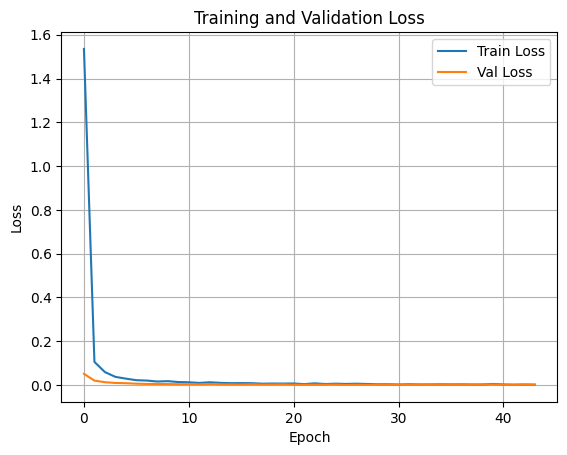

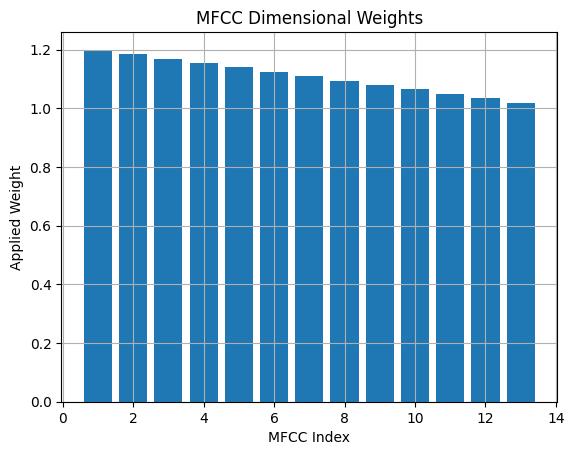

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import os

# Configuration
csv_path = "/content/drive/MyDrive/ICT_voice_detect_project/voice_mfcc_dataset.csv"
model_save_path = "/content/drive/MyDrive/ICT_voice_detect_project/dnn_best_model.pt"
input_dim = 13
hidden_dim = 32
output_dim = 1
batch_size = 64
num_epochs = 100
learning_rate = 0.001
patience = 10  # Early stopping patience

# MFCC importance weight (lower index = more important)
mfcc_weights = torch.tensor([1.2 - 0.015 * i for i in range(13)], dtype=torch.float32)

# Dataset
class MFCCDataset(Dataset):
    def __init__(self, dataframe):
        self.X = torch.tensor(dataframe.iloc[:, 2:].values, dtype=torch.float32)
        self.y = torch.tensor(dataframe.iloc[:, 1].values, dtype=torch.float32).unsqueeze(1)
        self.X *= mfcc_weights  # emphasize lower MFCC dimensions

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Load and split dataset
df = pd.read_csv(csv_path)
train_val_df, test_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['label'], random_state=42)

train_loader = DataLoader(MFCCDataset(train_df), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(MFCCDataset(val_df), batch_size=batch_size)
test_loader = DataLoader(MFCCDataset(test_df), batch_size=batch_size)

# DNN Model with Dropout and L2 Regularization
class DNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))
        return x

model = DNN(input_dim, hidden_dim, output_dim)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)  # L2 Regularization

# Training with Early Stopping
best_val_loss = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            outputs = model(X_val)
            val_loss += criterion(outputs, y_val).item()
            preds = (outputs >= 0.5).float()
            correct += (preds == y_val).sum().item()
            total += y_val.size(0)

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_acc = correct / total

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early Stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_save_path)
        patience_counter = 0
        print("✅ Best model saved.")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("⏹️ Early stopping triggered.")
            break

# Visualization
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Training and Validation Loss")
plt.grid(True)
plt.show()

plt.figure()
plt.bar(range(1, 14), mfcc_weights)
plt.xlabel("MFCC Index")
plt.ylabel("Applied Weight")
plt.title("MFCC Dimensional Weights")
plt.grid(True)
plt.show()


<ipython-input-1-7ceab4a15ed0>:13: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(wav_path, sr=sr_target)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
<ipython-input-1-7ceab4a15ed0>:13: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(wav_path, sr=sr_target)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
<ipython-input-1-7ceab4a15ed0>:13: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(wav_path, sr=sr_target)
/usr/local/lib/python3.11/dist-packages

스펙트로그램 이미지 저장 완료!
